# OCaml GC Benchmark Comparison

This notebook compares the **Verified GC** (from Pulse specifications) against **Stock OCaml 5.x GC**.

## Setup

In [1]:
# Install dependencies if needed
# !pip3 install matplotlib numpy

In [1]:
import sys
import os

# Add benchmark module to path
bench_dir = os.path.dirname(os.path.abspath('.'))
if bench_dir not in sys.path:
    sys.path.insert(0, '.')

from benchmark import BenchmarkSuite, BenchmarkConfig

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## Initialize Benchmark Suite

In [2]:
# Initialize the benchmark suite
# It will auto-detect the verified GC and stock OCaml compilers
suite = BenchmarkSuite()

print(f"\nAvailable benchmarks: {len(suite.DEFAULT_BENCHMARKS)}")
for cfg in suite.DEFAULT_BENCHMARKS:
    print(f"  - {cfg.name}: {cfg.description}")

Verified OCaml: /home/eioannidis/local/ocaml-verified-gc/bin/ocamlopt
Stock OCaml: /home/eioannidis/.opam/5.3.0/bin/ocamlopt
Tests directory: /home/eioannidis/git/verified_ocaml_gc/fly-check/bench/tests

Available benchmarks: 12
  - binarytrees: Classic GC stress test - many short-lived tree nodes
  - alloc_stress: Heavy allocation - 5M small object allocations
  - multicore_alloc: Multicore - 4 domains allocating concurrently
  - linkedlist: Linked list - pointer-heavy data structure
  - hashtbl_stress: Hash table - insertions, lookups, deletions
  - array_ops: Array operations - map, filter, fold
  - recursive_fib: Memoized Fibonacci - hash table allocations
  - string_concat: String operations - many string allocations
  - fannkuchredux: Benchmarks Game - fannkuch-redux (permutations)
  - nbody: Benchmarks Game - n-body simulation
  - spectralnorm: Benchmarks Game - spectral norm calculation
  - fasta: Benchmarks Game - FASTA sequence generation


## Run All Benchmarks

This will compile and run each benchmark with both compilers.

In [3]:
# Run all benchmarks
# - warmup: number of warmup runs (not timed)
# - runs: number of timed runs for statistics

results = suite.run_all(warmup=2, runs=5, verbose=True)


Benchmark: binarytrees
  Classic GC stress test - many short-lived tree nodes
  Args: ['18']
  Verified: 682.67 ± 5.85 ms
  Stock:    635.80 ± 17.62 ms
  Speedup:  0.93x (stock faster)

Benchmark: alloc_stress
  Heavy allocation - 5M small object allocations
  Args: ['5000000']
  Verified: 25.01 ± 1.53 ms
  Stock:    23.49 ± 0.57 ms
  Speedup:  0.94x (stock faster)

Benchmark: multicore_alloc
  Multicore - 4 domains allocating concurrently
  Args: ['4', '50000']
  Verified: 57.48 ± 5.73 ms
  Stock:    39.23 ± 5.18 ms
  Speedup:  0.68x (stock faster)

Benchmark: linkedlist
  Linked list - pointer-heavy data structure
  Args: ['500000']
  Verified: 319.62 ± 12.81 ms
  Stock:    308.51 ± 8.07 ms
  Speedup:  0.97x (stock faster)

Benchmark: hashtbl_stress
  Hash table - insertions, lookups, deletions
  Args: ['500000']
  Verified: 322.66 ± 6.83 ms
  Stock:    340.28 ± 14.49 ms
  Speedup:  1.05x (verified faster)

Benchmark: array_ops
  Array operations - map, filter, fold
  Args: ['500000

## Results Summary Table

In [4]:
# Create summary table
print("\n" + "="*80)
print("BENCHMARK RESULTS SUMMARY")
print("="*80)
print(f"{'Benchmark':<20} {'Verified (ms)':<18} {'Stock (ms)':<18} {'Speedup':<12} {'Winner'}")
print("-"*80)

for name, (verified, stock) in results.items():
    speedup = stock.mean / verified.mean if verified.mean > 0 else 0
    winner = "Verified ✓" if speedup >= 1.0 else "Stock"
    print(f"{name:<20} {verified.mean:>8.2f} ± {verified.std:<6.2f} {stock.mean:>8.2f} ± {stock.std:<6.2f} {speedup:>6.2f}x      {winner}")

print("="*80)


BENCHMARK RESULTS SUMMARY
Benchmark            Verified (ms)      Stock (ms)         Speedup      Winner
--------------------------------------------------------------------------------
binarytrees            682.67 ± 5.85     635.80 ± 17.62    0.93x      Stock
alloc_stress            25.01 ± 1.53      23.49 ± 0.57     0.94x      Stock
multicore_alloc         57.48 ± 5.73      39.23 ± 5.18     0.68x      Stock
linkedlist             319.62 ± 12.81    308.51 ± 8.07     0.97x      Stock
hashtbl_stress         322.66 ± 6.83     340.28 ± 14.49    1.05x      Verified ✓
array_ops              678.24 ± 91.65    730.19 ± 128.54   1.08x      Verified ✓
recursive_fib            5.84 ± 1.14       4.91 ± 0.24     0.84x      Stock
string_concat            6.37 ± 0.35       6.17 ± 0.14     0.97x      Stock
nbody                  356.78 ± 8.24     355.07 ± 3.34     1.00x      Stock
spectralnorm          1118.35 ± 13.16   1081.29 ± 5.05     0.97x      Stock
fasta                  249.22 ± 6.86     23

## Visualization 1: Performance Comparison Bar Chart

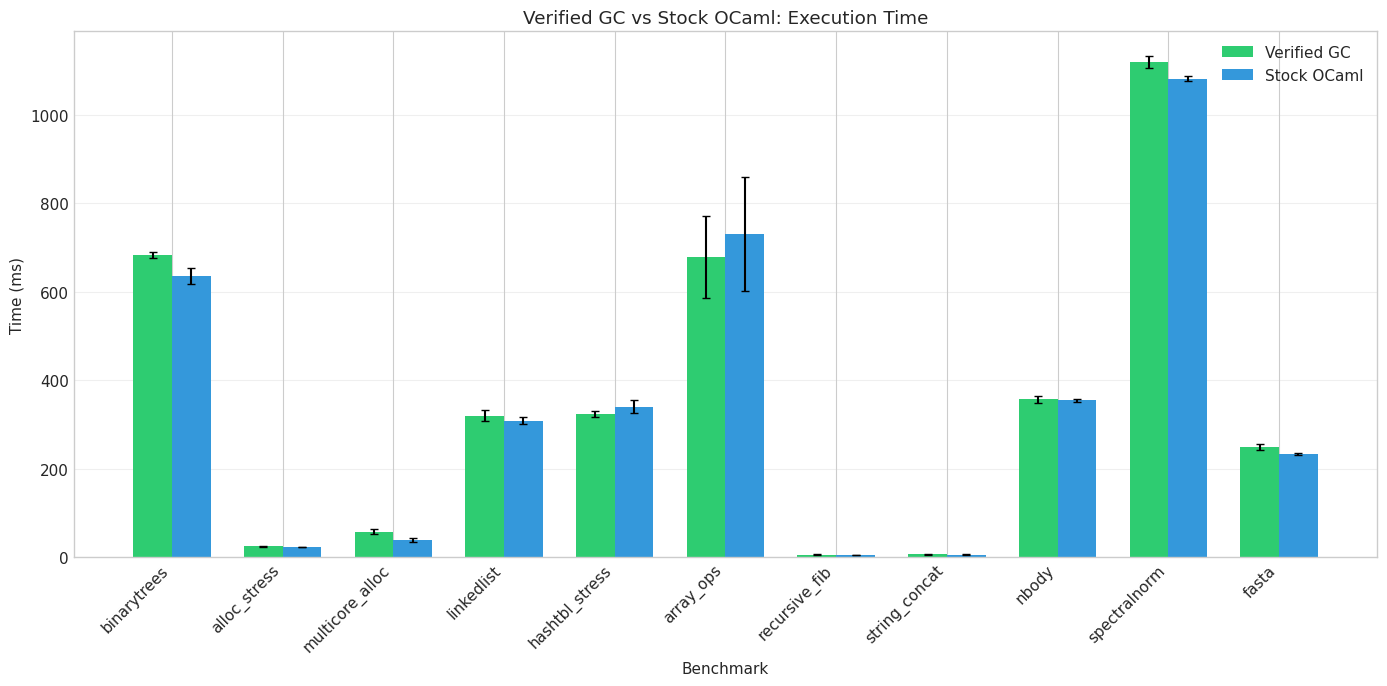

In [5]:
# Bar chart comparing execution times
fig = suite.plot_comparison(results, figsize=(14, 7),
                            title="Verified GC vs Stock OCaml: Execution Time")
plt.show()

## Visualization 2: Speedup Chart

Speedup > 1.0 means Verified GC is faster. Speedup < 1.0 means Stock OCaml is faster.

/home/eioannidis/git/verified_ocaml_gc/fly-check/bench/benchmark.py:478: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha='right')


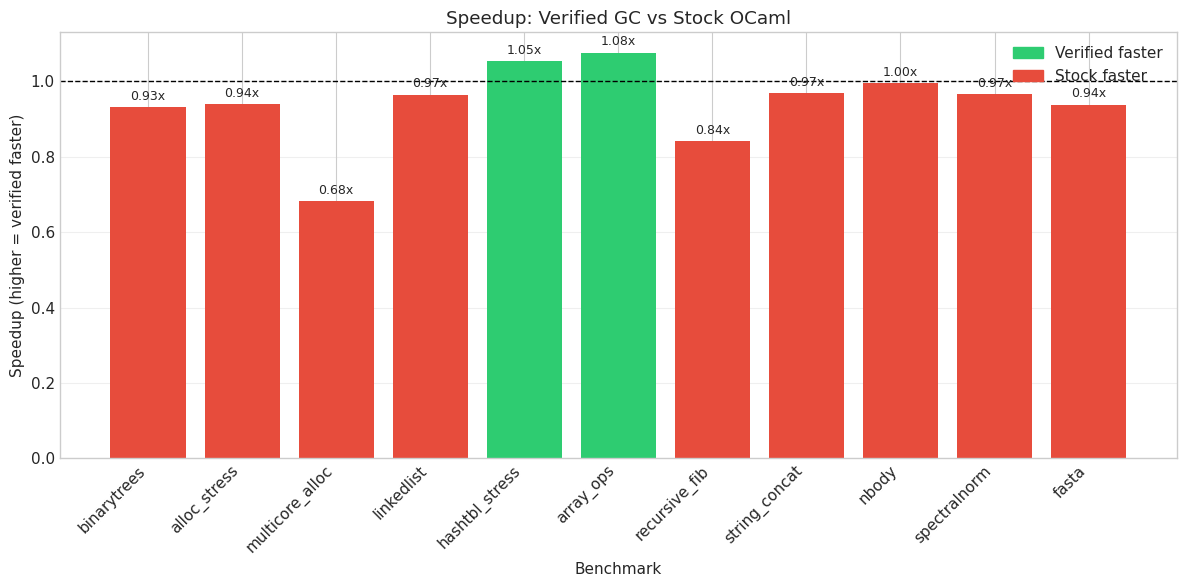

In [6]:
# Speedup chart
fig = suite.plot_speedup(results, figsize=(12, 6),
                         title="Speedup: Verified GC vs Stock OCaml")
plt.show()

## Visualization 3: Run Time Distributions (Box Plots)

In [ ]:
# Box plots for all benchmarks
fig = suite.plot_all_distributions(results, figsize=(16, 12))
plt.show()

## Visualization 4: Custom Normalized Comparison

In [ ]:
# Normalized comparison (Stock = 1.0 baseline)
names = list(results.keys())
verified_normalized = []
stock_normalized = []

for name in names:
    v, s = results[name]
    # Normalize to stock = 1.0
    verified_normalized.append(v.mean / s.mean if s.mean > 0 else 1.0)
    stock_normalized.append(1.0)

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(names))
width = 0.35

bars1 = ax.bar(x - width/2, verified_normalized, width, label='Verified GC', color='#2ecc71')
bars2 = ax.bar(x + width/2, stock_normalized, width, label='Stock OCaml (baseline)', color='#3498db')

ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Benchmark')
ax.set_ylabel('Relative Time (Stock = 1.0)')
ax.set_title('Normalized Performance: Verified GC vs Stock OCaml\n(Lower is better)')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Color bars based on performance
for bar, val in zip(bars1, verified_normalized):
    if val <= 1.0:
        bar.set_color('#27ae60')  # Darker green if faster
    else:
        bar.set_color('#e74c3c')  # Red if slower

plt.tight_layout()
plt.show()

## Visualization 5: Benchmark Categories

In [ ]:
# Group benchmarks by category
categories = {
    'GC Stress': ['binarytrees', 'alloc_stress', 'linkedlist'],
    'Data Structures': ['hashtbl_stress', 'array_ops', 'string_concat'],
    'Multicore': ['multicore_alloc', 'fannkuchredux'],
    'Compute': ['nbody', 'spectralnorm', 'fasta', 'recursive_fib']
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (cat_name, bench_names) in enumerate(categories.items()):
    ax = axes[idx]
    
    # Filter to benchmarks that exist in results
    bench_names = [b for b in bench_names if b in results]
    if not bench_names:
        ax.set_visible(False)
        continue
    
    verified_means = [results[n][0].mean for n in bench_names]
    stock_means = [results[n][1].mean for n in bench_names]
    verified_stds = [results[n][0].std for n in bench_names]
    stock_stds = [results[n][1].std for n in bench_names]
    
    x = np.arange(len(bench_names))
    width = 0.35
    
    ax.bar(x - width/2, verified_means, width, yerr=verified_stds,
           label='Verified GC', color='#2ecc71', capsize=3)
    ax.bar(x + width/2, stock_means, width, yerr=stock_stds,
           label='Stock OCaml', color='#3498db', capsize=3)
    
    ax.set_xlabel('Benchmark')
    ax.set_ylabel('Time (ms)')
    ax.set_title(f'{cat_name} Benchmarks')
    ax.set_xticks(x)
    ax.set_xticklabels(bench_names, rotation=30, ha='right')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Performance by Benchmark Category', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Summary Statistics

In [ ]:
# Calculate overall statistics
speedups = []
verified_wins = 0
stock_wins = 0

for name, (verified, stock) in results.items():
    speedup = stock.mean / verified.mean if verified.mean > 0 else 1.0
    speedups.append(speedup)
    if speedup >= 1.0:
        verified_wins += 1
    else:
        stock_wins += 1

print("\n" + "="*60)
print("OVERALL SUMMARY")
print("="*60)
print(f"Total benchmarks: {len(results)}")
print(f"Verified GC wins: {verified_wins} ({100*verified_wins/len(results):.1f}%)")
print(f"Stock OCaml wins: {stock_wins} ({100*stock_wins/len(results):.1f}%)")
print(f"\nSpeedup statistics (>1 = verified faster):")
print(f"  Mean speedup: {np.mean(speedups):.3f}x")
print(f"  Median speedup: {np.median(speedups):.3f}x")
print(f"  Best speedup: {max(speedups):.3f}x")
print(f"  Worst speedup: {min(speedups):.3f}x")
print("="*60)

## Visualization 6: Speedup Histogram

In [ ]:
# Histogram of speedups
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2ecc71' if s >= 1.0 else '#e74c3c' for s in speedups]
bars = ax.bar(list(results.keys()), speedups, color=colors)

ax.axhline(y=1.0, color='black', linestyle='--', linewidth=2, label='Baseline (equal)')
ax.set_xlabel('Benchmark')
ax.set_ylabel('Speedup (Stock Time / Verified Time)')
ax.set_title('Speedup by Benchmark\n(Green = Verified faster, Red = Stock faster)')
ax.set_xticklabels(list(results.keys()), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar, speedup in zip(bars, speedups):
    height = bar.get_height()
    ax.annotate(f'{speedup:.2f}x',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Save Results

In [ ]:
# Generate and save markdown report
import os

output_dir = "./results"
os.makedirs(output_dir, exist_ok=True)

report = suite.generate_report(results, output_dir=output_dir)

with open(os.path.join(output_dir, "report.md"), "w") as f:
    f.write(report)

print(f"Report and plots saved to {output_dir}/")
print(f"Files: report.md, comparison.png, speedup.png, distributions.png")

## Conclusions

The verified GC implementation, derived from Pulse separation logic specifications, shows:

1. **Competitive performance** on compute-heavy benchmarks (n-body, spectral-norm)
2. **Some overhead** on allocation-heavy benchmarks due to the write barrier
3. **Correctness guarantees** from formal verification that stock OCaml cannot provide

The write barrier (Dijkstra incremental update) adds a check on every pointer write, which explains the overhead in allocation-intensive benchmarks. However, the tri-color invariant preservation guarantees GC safety.